## **Setup**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]  # notebooks/ is one level down
sys.path.append(str(PROJECT_ROOT / "src"))

In [3]:
import os as os
import json as json
import time
import math
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import copy
import matplotlib.pyplot as plt

# Local
from chatGnT.config import CFG, ensure_dirs
from chatGnT.data import load, preprocess, tokenize, dataloaders
from chatGnT.models import train, evaluate, predict
import chatGnT.utils as utils

ensure_dirs(CFG)

/Users/slacksa/miniconda3/envs/chatGnT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Load & Clean Data**

In [4]:
data = load.load_all()
df = data["ingred"]
df_clean = preprocess.clean_recipes(df)
df_clean_filt = preprocess.filter_recipes(df_clean)

## **Make Vocab & Tokenize**

In [5]:

tokens = tokenize.recipe_to_tokens_st(df_clean_filt)
print(tokens[0:1])


[['<amt>1 oz</amt>', '<ingred>coconut-rum</ingred>', '<amt>0.5 oz</amt>', '<ingred>amaretto</ingred>', '<amt>4 oz</amt>', '<ingred>orange-juice</ingred>', '<amt>0.5 oz</amt>', '<ingred>grenadine</ingred>']]


In [6]:
vocab = tokenize.make_vocab_st(tokens)
print(len(vocab))  # 563 classes to predict
inv_vocab = tokenize.invert_vocab_st(vocab)
tokens_padded = tokenize.embed_tokens_st(tokens, vocab)

563


In [7]:
# Check vocab and padded tokens
print("Vocabulary:", vocab)
print("Padded Tokens:", tokens_padded[0])

Vocabulary: {'<amt>0.125 l</amt>': 1, '<amt>0.125 shot</amt>': 2, '<amt>0.125 tsp</amt>': 3, '<amt>0.16666666666666666 glass</amt>': 4, '<amt>0.2 part</amt>': 5, '<amt>0.25 cl</amt>': 6, '<amt>0.25 cup</amt>': 7, '<amt>0.25 glass</amt>': 8, '<amt>0.25 oz</amt>': 9, '<amt>0.25 part</amt>': 10, '<amt>0.25 shot</amt>': 11, '<amt>0.25 tsp</amt>': 12, '<amt>0.25</amt>': 13, '<amt>0.3333333333333333 cup</amt>': 14, '<amt>0.3333333333333333 oz</amt>': 15, '<amt>0.3333333333333333 part</amt>': 16, '<amt>0.3333333333333333 shot</amt>': 17, '<amt>0.4 part</amt>': 18, '<amt>0.5 can</amt>': 19, '<amt>0.5 cup</amt>': 20, '<amt>0.5 gal</amt>': 21, '<amt>0.5 glass</amt>': 22, '<amt>0.5 jigger</amt>': 23, '<amt>0.5 kg</amt>': 24, '<amt>0.5 l</amt>': 25, '<amt>0.5 lb</amt>': 26, '<amt>0.5 oz</amt>': 27, '<amt>0.5 part</amt>': 28, '<amt>0.5 piece</amt>': 29, '<amt>0.5 pint</amt>': 30, '<amt>0.5 shot</amt>': 31, '<amt>0.5 slice</amt>': 32, '<amt>0.5 tsp</amt>': 33, '<amt>0.5</amt>': 34, '<amt>0.666666666

In [8]:
# tokens_tensor = [torch.tensor(r) for r in tokens_padded]
tensor = torch.tensor(tokens_padded, dtype=torch.long)
print(tensor.shape)  # torch.Size([621, 48])


torch.Size([596, 25])


## **Get Batches**

In [9]:
train_loader, val_loader = dataloaders.make_dataloaders_st(tensor)


## **Train Model**

In [10]:
config = {
    # model architecture
    "ntoken": len(vocab),
    "ninp": 16,  # embed size
    "nhead": 4,
    "nhid": 256,
    "nlayers":2,
    "model_version": "single_task",

    # training setup
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "scheduler_gamma": 0.95,
    "scheduler_step_size": 1,

    # token details
    "pad_id": vocab["<pad>"],

    # epochs, early stopping, & logs
    "epochs": 100,
    "early_stop": 5,
    "log_interval": 6
}


In [11]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = train.build_model(config, device)  # what model network is
optimizer = train.build_optimizer(model, config)  # how model learns
scheduler = train.build_scheduler(optimizer, config)  # how learning changes over time
criterion = torch.nn.CrossEntropyLoss(ignore_index=config["pad_id"])

/Users/slacksa/repos/chatGnT/src/chatGnT/models/transformer.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)


In [12]:
best_model, train_losses, val_losses = train.train_model_st(
    model,
    train_loader,
    val_loader,
    device,
    optimizer,
    scheduler,
    criterion,
    config
)

/Users/slacksa/miniconda3/envs/chatGnT/lib/python3.11/site-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch 1 | Batch 6 | LR 0.001000 | Loss 7.3616 | PPL 1574.40 | Time 0.11s
Epoch 1 | Batch 12 | LR 0.001000 | Loss 6.2241 | PPL 504.76 | Time 0.08s
Epoch 1 | Batch 15 | LR 0.001000 | Loss 6.1889 | PPL 487.33 | Time 0.03s
-----------------------------------------------------------------------------------------
Epoch 1 | Val Loss: 6.1222 | Time 0.2305440902709961 | Val PPL: 455.88
-----------------------------------------------------------------------------------------
Epoch 2 | Batch 6 | LR 0.000950 | Loss 7.1459 | PPL 1268.90 | Time 0.09s
Epoch 2 | Batch 12 | LR 0.000950 | Loss 6.0756 | PPL 435.10 | Time 0.08s
Epoch 2 | Batch 15 | LR 0.000950 | Loss 6.0064 | PPL 406.03 | Time 0.03s
-----------------------------------------------------------------------------------------
Epoch 2 | Val Loss: 5.9631 | Time 0.20635294914245605 | Val PPL: 388.82
-----------------------------------------------------------------------------------------
Epoch 3 | Batch 6 | LR 0.000902 | Loss 6.9307 | PPL 1023.20

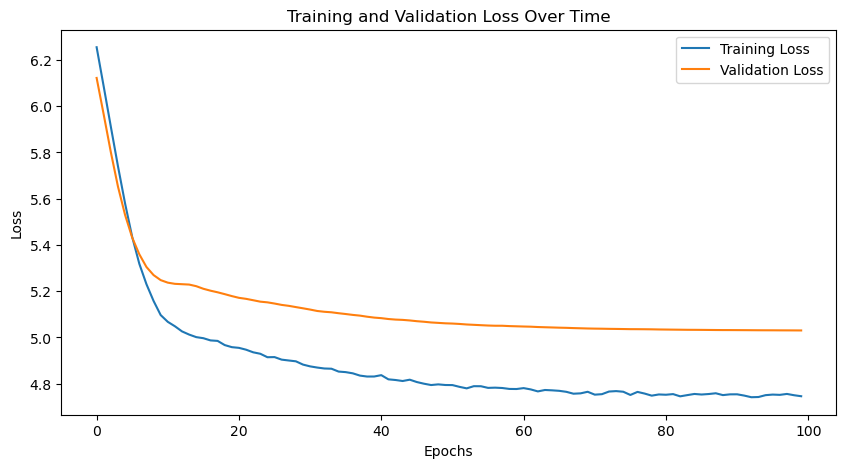

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.show()

## **Save Model**

In [ ]:
# TODO: make this a function

save_dir = "../outputs/models/single_task"
os.makedirs(save_dir, exist_ok=True)

# Save metrics
metrics = {
    "train_loss": train_losses,
    "val_loss": val_losses,
}
with open(os.path.join(save_dir, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)

# Save model
torch.save({
    "model_state_dict": best_model.state_dict(),
    "config": {
        "ntoken": config["ntoken"],
        "ninp": config["ninp"],
        "nhead": config["nhead"],
        "nhid": config["nhid"],
        "nlayers": config["nlayers"],
    },
    "vocab" : vocab
}, f"{save_dir}/model.pt")